# Neural-Network Quantum State Tomography
### Based on Koutný et al., *arXiv:2206.06736*

---

## 1. What is Quantum State Tomography?


Quantum State Tomography (QST) is the experimental procedure of reconstructing an unknown 
quantum state $\rho$ — a $d \times d$ positive semidefinite, unit-trace density matrix — 
from measurement statistics collected on many identical copies of the system.

Given a POVM $\{\Pi_\ell\}$ satisfying $\Pi_\ell \geq 0$ and $\sum_\ell \Pi_\ell = \mathbb{I}$, 
Born's rule gives the probability of outcome $\ell$:

$$p_\ell = \mathrm{Tr}(\rho\, \Pi_\ell)$$

In practice we observe **frequencies** $f_\ell = n_\ell / N$ (counts divided by total shots), 
which converge to $p_\ell$ as $N \to \infty$. The inverse problem is: given $\mathbf{f}$, 
reconstruct $\rho$.

---

## 2. Classical Estimators

### 2.1 Linear Inversion (LI)
The simplest approach treats $\mathbf{p} = C\mathbf{r}$ as a linear system 
(where $\mathbf{r}$ is the Bloch vector of $\rho$ and $C_{\ell k} = \mathrm{Tr}(\Pi_\ell \Gamma_k)$ 
is the measurement matrix), and solves it via pseudoinverse:

$$\hat{\mathbf{r}}_\mathrm{LI} = C^- \mathbf{f}$$

**Problem:** The resulting state is not guaranteed to be positive semidefinite 
— it can return unphysical states with negative eigenvalues. In the other Jupyter notebook, we implement a single-qubit state tomography using LI.

### 2.2 Maximum Likelihood Estimation (MLE)
MLE finds the physical state $\rho \geq 0$, $\mathrm{Tr}\,\rho = 1$ that maximises 
the likelihood of the observed data. The standard algorithm is the iterative $R\rho R$ map:

$$\rho_{k+1} = \lambda_k\, R\, \rho_k\, R, \qquad R = \sum_j \frac{f_j}{p_j} \Pi_j$$

MLE is **asymptotically optimal** (saturates the Cramér–Rao bound) but requires 
thousands of iterations to converge — making it slow for large systems. In the other Jupyter notebook, we implement a single-qubit state tomography using a MLE method.


---

## 3. Neural-Network QST — Core Idea

Koutný et al. (2022) propose training a standard feedforward neural network to directly 
map frequency vectors $\mathbf{f}$ to density matrices, learning the inversion 
$\mathbf{f} \mapsto \rho$ from simulated data.

The key challenge is the **positivity constraint**: a naive regression can output matrices 
with negative eigenvalues. The paper solves this with the **Cholesky parametrisation**.

### 3.1 Cholesky Parametrisation (Positivity by Construction)

Any valid density matrix can be written as:

$$\rho = \frac{A A^\dagger}{\mathrm{Tr}(A A^\dagger)}$$

where $A$ is a complex lower-triangular matrix. This parametrisation **always** produces 
a positive semidefinite, unit-trace state — physical validity is guaranteed by construction.

For dimension $d$, $A$ has $d^2$ independent real parameters:
- $d$ real diagonal entries
- $\frac{d(d-1)}{2}$ complex off-diagonal entries (2 reals each)

The network learns to output these $d^2$ parameters, which are then assembled into $A$ 
and converted to $\rho$.

### 3.2 Network Architecture

$$\mathbf{f} \;\xrightarrow{\text{Linear}+\text{ReLU}} \cdots \xrightarrow{\text{Linear}+\text{ReLU}} \xrightarrow{\text{Linear}+\tanh} \hat{\mathbf{a}}$$

| Layer | Activation | Purpose |
|---|---|---|
| Input | — | Frequency vector $\mathbf{f} \in \mathbb{R}^m$ |
| Hidden ($\times 4$) | ReLU | Non-linear feature extraction |
| Output | $\tanh$ | Maps to $(-1,1)$, matching Cholesky parameter range |

The $\tanh$ output layer is chosen because both Bloch vector components and 
(after soft-scaling) Cholesky matrix elements naturally live in $(-1, 1)$.

### 3.3 Loss Function

Training minimises the **mean squared error on the Cholesky parameters** 
(not on $\rho$ directly, for computational efficiency):

$$\mathcal{L} = \left\langle \sum_{k=0}^{n} \left| a_k - z_k^\mathrm{out}(\tilde{W}, \mathbf{f}) \right|^2 \right\rangle_\rho$$

where $\langle \cdot \rangle_\rho$ denotes the average over training states.

---

## 4. Performance Metric

We use the **Hilbert–Schmidt distance** to compare true and estimated states:

$$d_\mathrm{HS}(\rho_1, \rho_2) = \mathrm{Tr}\!\left[(\rho_1 - \rho_2)^2\right]$$

and the **quantum fidelity**:

$$F(\rho_1, \rho_2) = \left(\mathrm{Tr}\!\sqrt{\sqrt{\rho_1}\,\rho_2\,\sqrt{\rho_1}}\right)^2$$

Koutný et al. show that the NN achieves **similar accuracy to MLE** across all dimensions 
tested ($d = 3, 5, 7, 9$), while being roughly **three orders of magnitude faster** 
at inference time.

---

## 5. This Implementation

This notebook implements the 
NN-based estimator and reproduces the paper's main benchmarking experiment.

| Component | Library |
|---|---|
| Quantum objects (POVM, $\rho$, fidelity) | `QuTiP` |
| Neural network & autograd | `PyTorch` |
| Random state generation | Ginibre ensemble (NumPy) |
| Baselines | LI (NumPy pseudoinverse) + MLE ($R\rho R$ iterator) |



In [1]:
# Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import cholesky, LinAlgError
import qutip as qt
import warnings
warnings.filterwarnings("ignore")
 


A **POVM** (Positive Operator-Valued Measure) is a set of operators $\{\Pi_\ell\}$ satisfying
$\Pi_\ell \geq 0$ and $\sum_\ell \Pi_\ell = \mathbb{I}$, representing the possible outcomes
of a quantum measurement.

We use a single function `pauli_povm(d)` that constructs an informationally-complete POVM
depending on the system dimension:

- **$d=2$ (qubit):** the $\pm 1$ eigenstates of $\sigma_x, \sigma_y, \sigma_z$ are turned
  into rank-1 projectors scaled by $\frac{1}{3}$, giving **6 POVM elements** that sum to $\mathbb{I}$.
- **$d>2$:** $d^2$ random complex unit vectors drawn from the Ginibre ensemble are formed
  into rank-1 projectors scaled by $\frac{1}{d}$, giving an informationally-complete
  frame with **$d^2$ elements**.

In both cases, Born's rule $p_\ell = \mathrm{Tr}(\rho\,\Pi_\ell)$ gives the theoretical
outcome probabilities, from which multinomial counts are sampled and normalised into the
**frequency vector** $\mathbf{f}$ — the input to the neural network.

In [2]:
#  POVM CONSTRUCTION  (QuTiP)


def pauli_povm(d=2):
    """
    Build an informationally-complete POVM from Pauli-basis projectors.

    For a qubit (d=2): measures in X, Y, Z bases → 6 rank-1 projectors.
    For higher dimensions: uses SIC-POVM via random unitary frame.

    Returns
    -------
    list of qutip.Qobj
        POVM elements {Π_l}, each a d×d positive Hermitian operator.
        They sum to the identity (up to a scalar for the scaled versions).
    """
    if d == 2:
        # Projectors onto the ±1 eigenstates of X, Y, Z (scaled by 1/3 for POVM)
        sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
        I = qt.qeye(2)
        povms = []
        for op in [sx, sy, sz]:
            evals, evecs = op.eigenstates()
            for vec in evecs:
                povms.append((vec * vec.dag()) / 3)   # scale so they sum to I
        return povms
    else:
        # Generalised: use d² rank-1 projectors from a random unitary
        # This gives a tight frame / SIC-like POVM
        np.random.seed(42)
        povms = []
        for _ in range(d * d):
            v = np.random.randn(d) + 1j * np.random.randn(d)
            v /= np.linalg.norm(v)
            P = np.outer(v, v.conj())
            # Scale so sum ≈ I
            povms.append(qt.Qobj(P / d))
        return povms

Simulating measurements: 

`born_probabilities(rho, povms)` computes the theoretical outcome probabilities
$p_\ell = \mathrm{Tr}(\rho\,\Pi_\ell)$ for each POVM element using QuTiP, returning
a normalised real vector $\mathbf{p} \in \mathbb{R}^m$.
 `simulate_frequencies(rho, povms, n_shots)` draws multinomial counts from $\mathbf{p}$
over $N$ shots and divides by $N$, returning the **frequency vector**
$f_\ell = n_\ell / N$. Since we have no access to a real quantum device, both the
states $\rho$ and the measurement outcomes are fully simulated — $\mathbf{f}$ is a
finite-sample, noisy estimate of $\mathbf{p}$ that serves as the input to the neural network.

In [3]:

def born_probabilities(rho, povms):
    """
    Compute theoretical Born-rule probabilities p_l = Tr(ρ Π_l).

    Parameters
    ----------
    rho   : qutip.Qobj  density matrix
    povms : list of qutip.Qobj

    Returns
    -------
    np.ndarray  shape (m,), real, sums to 1
    """
    probs = np.array([(rho * Pi).tr().real for Pi in povms], dtype=np.float64)
    probs = np.clip(probs, 0, None)
    probs /= probs.sum()
    return probs


def simulate_frequencies(rho, povms, n_shots):
    """
    Draw multinomial samples and return frequency vector f.

    Parameters
    ----------
    rho     : qutip.Qobj
    povms   : list of qutip.Qobj
    n_shots : int  number of measurements

    Returns
    -------
    np.ndarray  shape (m,), floats in [0,1] summing to 1
    """
    probs = born_probabilities(rho, povms)
    counts = np.random.multinomial(n_shots, probs)
    return counts.astype(np.float32) / n_shots


Random State Generation: `random_density_matrix(d, rank)` generates a random valid density matrix using the
**Ginibre ensemble**: a random complex matrix $G \in \mathbb{C}^{d \times r}$ is drawn
with Gaussian entries, and $\rho = GG^\dagger / \mathrm{Tr}(GG^\dagger)$ is formed —
guaranteeing positive semidefiniteness and unit trace by construction.

It is called once per sample in `build_dataset` to generate the true state $\rho$,
which is then measured to produce the network input $\mathbf{f}$ and encoded into
Cholesky parameters as the training target $\mathbf{a}$.

In [4]:
# RANDOM STATE GENERATION  (QuTiP)


def random_density_matrix(d, rank=None):
    """
    Generate a Haar-random mixed state via the Ginibre ensemble.

    ρ = G G† / Tr(G G†),  G ∈ ℂ^{d×r},  r = rank (default: d → full rank)

    Parameters
    ----------
    d    : int  Hilbert space dimension
    rank : int  rank of the state (None = full rank)

    Returns
    -------
    qutip.Qobj  density matrix
    """
    r = rank or d
    G = (np.random.randn(d, r) + 1j * np.random.randn(d, r)) / np.sqrt(2)
    rho_np = G @ G.conj().T
    rho_np /= np.trace(rho_np)
    return qt.Qobj(rho_np)



Cholesky Parameterization of Density Matrices: Density matrices ρ must be positive semidefinite and trace equal to 1. Rather than predicting ρ directly and projecting onto the valid set, we parameterize via the Cholesky factor: ρ = AA†/Tr(AA†), where A is lower-triangular complex. Any vector the network outputs is guaranteed to map to a physical state.

**Encoding** (`rho_to_cholesky_vec`): extracts A from ρ, flattens it into a real vector of length d² (diagonal entries real-valued, off-diagonal entries as re/im pairs), and applies tanh to match the network's output range.

**Decoding** (`cholesky_vec_to_rho`, `cholesky_vec_to_rho_torch`): applies arctanh, reconstructs A, and computes ρ = AA†/Tr(AA†). The NumPy version handles single states for evaluation; the PyTorch version is batch-compatible for use during training.

In [5]:

# CHOLESKY PARAMETRISATION


def rho_to_cholesky_vec(rho_qt, d):
    """
    Extract the Cholesky factor A from ρ = A A† / Tr(A A†)
    and flatten it into a real vector of length d².

    Layout: diagonal entries (real) + off-diagonal entries (re, im pairs).

    Parameters
    ----------
    rho_qt : qutip.Qobj
    d      : int

    Returns
    -------
    np.ndarray  shape (d²,), dtype float32, values in (-1, 1) after tanh scaling
    """
    rho_np = rho_qt.full()
    # Add small regularisation for numerical stability
    rho_reg = rho_np + 1e-8 * np.eye(d)
    rho_reg /= np.trace(rho_reg)

    try:
        L = cholesky(rho_reg, lower=True)
    except LinAlgError:
        L = np.eye(d, dtype=complex)

    params = []
    for i in range(d):
        for j in range(i + 1):
            if i == j:
                params.append(float(L[i, j].real))
            else:
                params.append(float(L[i, j].real))
                params.append(float(L[i, j].imag))

    params = np.array(params, dtype=np.float32)
    # Soft-clip to (-1, 1) so tanh output range is matched
    params = np.tanh(params)
    return params


def cholesky_vec_to_rho(vec, d):
    """
    Reconstruct density matrix from a real Cholesky parameter vector.
    Works on numpy arrays (single state).

    Parameters
    ----------
    vec : np.ndarray  shape (d²,)
    d   : int

    Returns
    -------
    qutip.Qobj  valid density matrix (positive, trace-1)
    """
    # Inverse tanh to recover L entries
    vec = np.arctanh(np.clip(vec, -0.9999, 0.9999))
    A = np.zeros((d, d), dtype=complex)
    idx = 0
    for i in range(d):
        for j in range(i + 1):
            if i == j:
                A[i, j] = vec[idx]
                idx += 1
            else:
                A[i, j] = vec[idx] + 1j * vec[idx + 1]
                idx += 2

    rho_np = A @ A.conj().T
    tr = np.trace(rho_np).real
    if tr < 1e-10:
        return qt.qeye(d) / d
    rho_np /= tr
    return qt.Qobj(rho_np)


def cholesky_vec_to_rho_torch(params, d):
    """
    Reconstruct density matrix tensor from Cholesky params.
    Batch-compatible PyTorch version used during training.

    Parameters
    ----------
    params : torch.Tensor  shape (batch, d²)
    d      : int

    Returns
    -------
    torch.Tensor  shape (batch, d, d) complex64
    """
    batch = params.shape[0]
    device = params.device
    # Inverse tanh
    p = torch.arctanh(params.clamp(-0.9999, 0.9999))
    A = torch.zeros(batch, d, d, dtype=torch.complex64, device=device)
    idx = 0
    for i in range(d):
        for j in range(i + 1):
            if i == j:
                A[:, i, j] = p[:, idx].to(torch.complex64)
                idx += 1
            else:
                A[:, i, j] = (p[:, idx] + 1j * p[:, idx + 1]).to(torch.complex64)
                idx += 2
    # ρ = A A† / Tr(A A†)
    rho = torch.bmm(A, A.conj().transpose(1, 2))
    tr = rho.diagonal(dim1=-2, dim2=-1).real.sum(-1).clamp(min=1e-10)
    rho = rho / tr[:, None, None]
    return rho


Define function to generate dataset and class for NN architecture.

In [6]:
# DATASET GENERATION


def build_dataset(n_samples, d, povms, n_shots, rank=None, seed=None):
    """
    Generate (frequency_vector, cholesky_params) pairs for training/testing.

    Parameters
    ----------
    n_samples : int
    d         : int
    povms     : list of qutip.Qobj
    n_shots   : int  measurements per state
    rank      : int or None
    seed      : int or None

    Returns
    -------
    X : torch.Tensor  shape (n_samples, m)   — frequency vectors (inputs)
    Y : torch.Tensor  shape (n_samples, d²)  — Cholesky params  (targets)
    rhos : list of qutip.Qobj                — true density matrices
    """
    if seed is not None:
        np.random.seed(seed)

    X_list, Y_list, rhos = [], [], []
    for _ in range(n_samples):
        rho = random_density_matrix(d, rank=rank)
        f   = simulate_frequencies(rho, povms, n_shots)
        y   = rho_to_cholesky_vec(rho, d)
        X_list.append(f)
        Y_list.append(y)
        rhos.append(rho)

    X = torch.tensor(np.array(X_list), dtype=torch.float32)
    Y = torch.tensor(np.array(Y_list), dtype=torch.float32)
    return X, Y, rhos


# NEURAL NETWORK ARCHITECTURE


class QSTNet(nn.Module):
    """
    Feed-forward neural network for QST as described in Koutný et al.

    Architecture
    ─────────────
    Input  → [Linear → ReLU] × n_hidden → Linear → Tanh → Output

    The tanh output layer matches the (-1,1) range of tanh-scaled
    Cholesky parameters (and Bloch vector components).
    """

    def __init__(self, input_dim, output_dim, hidden_dim=512, n_hidden=4):
        """
        Parameters
        ----------
        input_dim  : int  number of POVM outcomes (= len(povms))
        output_dim : int  number of Cholesky params (= d²)
        hidden_dim : int  neurons per hidden layer
        n_hidden   : int  number of hidden layers
        """
        super().__init__()

        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers += [nn.Linear(hidden_dim, output_dim), nn.Tanh()]

        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

    def n_params(self):
        return sum(p.numel() for p in self.parameters())



In [7]:
# FIDELITY & HILBERT-SCHMIDT DISTANCE


def hilbert_schmidt_distance_qutip(rho1, rho2):
    """
    d_HS(ρ₁, ρ₂) = Tr[(ρ₁ - ρ₂)²]

    Parameters
    ----------
    rho1, rho2 : qutip.Qobj

    Returns
    -------
    float
    """
    diff = rho1 - rho2
    return ((diff * diff).tr()).real


def fidelity_qutip(rho1, rho2):
    """
    F(ρ₁, ρ₂) = (Tr[√(√ρ₁ ρ₂ √ρ₁)])²
    Uses QuTiP's built-in fidelity.
    """
    return qt.fidelity(rho1, rho2) ** 2


Define functions to perform Quantum state tomography using LI and MLE.

In [8]:
#  ESTIMATORS


def linear_inversion(f, povms, d):
    """
    Linear inversion: r̂_LI = C⁻ f  (pseudoinverse).

    Reconstructs a Hermitian operator from frequencies.
    NOT guaranteed to be positive semidefinite.

    Parameters
    ----------
    f     : np.ndarray  frequency vector shape (m,)
    povms : list of qutip.Qobj
    d     : int

    Returns
    -------
    qutip.Qobj  (may not be a valid density matrix)
    """
    m = len(povms)
    # Build measurement matrix C: C[l,k] = Tr(Π_l Γ_k)
    # We use the flattened real/imag vectorisation of ρ
    # Simple approach: solve min ||f - p||² s.t. linear
    # Represent ρ as flat complex vector, use least-squares

    # Vectorise: ρ → vec(ρ) ∈ ℂ^{d²}
    # p_l = Tr(Π_l ρ) = vec(Π_l†)ᵀ vec(ρ)
    C = np.zeros((m, d * d), dtype=complex)
    for l, Pi in enumerate(povms):
        Pi_np = Pi.full()
        C[l, :] = Pi_np.conj().T.flatten()

    # Real system: separate real and imag
    C_r = np.block([[C.real, -C.imag], [C.imag, C.real]])
    f_r = np.concatenate([f, np.zeros(m)])
    x, _, _, _ = np.linalg.lstsq(C_r, f_r, rcond=None)
    rho_vec = x[:d*d] + 1j * x[d*d:]
    rho_np = rho_vec.reshape(d, d)

    # Symmetrise
    rho_np = (rho_np + rho_np.conj().T) / 2
    tr = np.trace(rho_np).real
    if abs(tr) > 1e-10:
        rho_np /= tr
    return qt.Qobj(rho_np)


def mle_estimate(f, povms, d, n_iter=2000, tol=1e-8):
    """
    Maximum-Likelihood Estimation via the R-ρ-R iterative algorithm.

    ρ_{k+1} = λ_k R ρ_k R,   R = Σ_j (f_j/p_j) Π_j

    Parameters
    ----------
    f       : np.ndarray  frequency vector
    povms   : list of qutip.Qobj
    d       : int
    n_iter  : int  max iterations
    tol     : float  convergence tolerance

    Returns
    -------
    qutip.Qobj  valid density matrix
    """
    # Initialise with maximally mixed state
    rho = qt.qeye(d) / d
    povms_np = [Pi.full() for Pi in povms]

    for _ in range(n_iter):
        rho_np = rho.full()
        probs = np.array([np.real(np.trace(rho_np @ Pi)) for Pi in povms_np])
        probs = np.clip(probs, 1e-10, None)

        R = sum((f[l] / probs[l]) * povms_np[l] for l in range(len(povms)))
        rho_new_np = R @ rho_np @ R
        tr = np.trace(rho_new_np).real
        if tr < 1e-10:
            break
        rho_new_np /= tr
        rho_new = qt.Qobj(rho_new_np)

        # Check convergence
        delta = hilbert_schmidt_distance_qutip(rho_new, rho)
        rho = rho_new
        if delta < tol:
            break

    return rho

Define training function:

In [9]:


# TRAINING

def train_model(model, X_train, Y_train, X_val, Y_val,
                epochs=200, batch_size=256, lr=1e-3, device='cpu'):
    """
    Train the QSTNet with MSE loss on Cholesky parameters.

    Parameters
    ----------
    model         : QSTNet
    X_train/Y_train : torch.Tensor  training data
    X_val/Y_val   : torch.Tensor    validation data
    epochs        : int
    batch_size    : int
    lr            : float  initial learning rate
    device        : str

    Returns
    -------
    dict  with keys 'train_loss', 'val_loss' (lists)
    """
    model = model.to(device)
    X_train, Y_train = X_train.to(device), Y_train.to(device)
    X_val,   Y_val   = X_val.to(device),   Y_val.to(device)

    dataset = TensorDataset(X_train, Y_train)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}

    print(f"\n{'Epoch':>6} | {'Train MSE':>10} | {'Val MSE':>10} | {'LR':>8}")
    print("─" * 44)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for X_b, Y_b in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b), Y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_b.size(0)

        train_loss /= len(X_train)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), Y_val).item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 20 == 0 or epoch == 1:
            lr_now = scheduler.get_last_lr()[0]
            print(f"{epoch:>6} | {train_loss:>10.6f} | {val_loss:>10.6f} | {lr_now:>8.2e}")

    return history



Evaluation of NN results using HS distance and fidelity metrics. Comparison to LI and MLE based on HS distance.

In [10]:
def evaluate_nn(model, X_test, rhos_true, d, device='cpu'):
    """
    Predict density matrices with the NN and compute HS distances + fidelities.

    Parameters
    ----------
    model     : QSTNet (trained)
    X_test    : torch.Tensor  shape (n_test, m)
    rhos_true : list of qutip.Qobj
    d         : int

    Returns
    -------
    dict with 'hs_distances', 'fidelities', 'rhos_pred'
    """
    model.eval()
    model = model.to(device)
    X_test = X_test.to(device)

    with torch.no_grad():
        params_pred = model(X_test).cpu().numpy()

    rhos_pred   = [cholesky_vec_to_rho(p, d) for p in params_pred]
    hs_dists    = [hilbert_schmidt_distance_qutip(rp, rt)
                   for rp, rt in zip(rhos_pred, rhos_true)]
    fidelities  = [fidelity_qutip(rp, rt)
                   for rp, rt in zip(rhos_pred, rhos_true)]

    return {
        'hs_distances': np.array(hs_dists),
        'fidelities':   np.array(fidelities),
        'rhos_pred':    rhos_pred,
    }


def evaluate_baselines(X_test_np, rhos_true, povms, d, n_jobs=None):
    """
    Run Linear Inversion and MLE on all test states.

    Parameters
    ----------
    X_test_np : np.ndarray  shape (n_test, m) frequency vectors
    rhos_true : list of qutip.Qobj
    povms     : list of qutip.Qobj
    d         : int

    Returns
    -------
    dict with 'li' and 'mle' sub-dicts, each containing
          'hs_distances', 'fidelities'
    """
    n = len(rhos_true)
    li_hs, li_fi, mle_hs, mle_fi = [], [], [], []

    print(f"\nEvaluating baselines on {n} test states...")
    for i, (f, rho_true) in enumerate(zip(X_test_np, rhos_true)):
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{n}")

        rho_li  = linear_inversion(f, povms, d)
        rho_mle = mle_estimate(f, povms, d)

        li_hs.append(hilbert_schmidt_distance_qutip(rho_li,  rho_true))
        li_fi.append(fidelity_qutip(rho_li,  rho_true))
        mle_hs.append(hilbert_schmidt_distance_qutip(rho_mle, rho_true))
        mle_fi.append(fidelity_qutip(rho_mle, rho_true))

    return {
        'li':  {'hs_distances': np.array(li_hs),  'fidelities': np.array(li_fi)},
        'mle': {'hs_distances': np.array(mle_hs), 'fidelities': np.array(mle_fi)},
    }



Evaluating reconstruction accuracy of all three estimators (NN, LI, MLE) as a function of shot count. Test states are fixed, isolating the effect of measurement noise on each method.

In [11]:
# HS DISTANCE vs. SHOT COUNT EXPERIMENT


def shot_scaling_experiment(model, rhos_test, povms, d,
                            shot_counts=None, device='cpu'):
    """
    Evaluate all estimators across different numbers of measurement shots.
    Reproduces Figure 2 from the paper.

    Parameters
    ----------
    model      : QSTNet (trained at one shot count; re-evaluated here)
    rhos_test  : list of qutip.Qobj  fixed test states
    povms      : list of qutip.Qobj
    d          : int
    shot_counts: list of int

    Returns
    -------
    dict  keyed by 'nn', 'li', 'mle', each containing arrays of mean HS dist
    """
    if shot_counts is None:
        shot_counts = [10, 50, 100, 500, 1000, 5000, 10000]

    results = {'shots': shot_counts, 'nn': [], 'li': [], 'mle': []}

    for shots in shot_counts:
        print(f"\n  shots = {shots}")
        # Re-sample frequencies for each shot count
        X_resamp = []
        for rho in rhos_test:
            f = simulate_frequencies(rho, povms, shots)
            X_resamp.append(f)
        X_t = torch.tensor(np.array(X_resamp, dtype=np.float32))

        nn_res = evaluate_nn(model, X_t, rhos_test, d, device=device)
        results['nn'].append(nn_res['hs_distances'].mean())

        bl = evaluate_baselines(X_t.numpy(), rhos_test, povms, d)
        results['li'].append(bl['li']['hs_distances'].mean())
        results['mle'].append(bl['mle']['hs_distances'].mean())

    return results


Define plotting functions:

In [13]:
# VISUALISATION

def plot_training_history(history, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(history['train_loss'], label='Train MSE', color='royalblue', lw=2)
    ax.semilogy(history['val_loss'],   label='Val MSE',   color='tomato',    lw=2, ls='--')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MSE Loss (log scale)', fontsize=12)
    ax.set_title('Training History', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_hs_comparison(nn_hs, bl_hs, title='HS Distance Comparison', save_path=None):
    """Bar chart of mean HS distance for NN, LI, MLE."""
    labels = ['Linear Inv.', 'MLE', 'NN (Cholesky)']
    means  = [bl_hs['li']['hs_distances'].mean(),
               bl_hs['mle']['hs_distances'].mean(),
               nn_hs['hs_distances'].mean()]
    stds   = [bl_hs['li']['hs_distances'].std(),
               bl_hs['mle']['hs_distances'].std(),
               nn_hs['hs_distances'].std()]
    colors = ['steelblue', 'seagreen', 'tomato']

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors,
                  edgecolor='black', linewidth=0.8, alpha=0.85)
    ax.set_ylabel('Mean HS Distance', fontsize=12)
    ax.set_title(title, fontsize=13)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
                f'{m:.4f}', ha='center', va='bottom', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_shot_scaling(results, save_path=None):
    """Reproduce Figure 2: HS distance vs. shot count."""
    shots = results['shots']
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.loglog(shots, results['li'],  'o--', color='steelblue', label='Linear Inv.', lw=2)
    ax.loglog(shots, results['mle'], 's--', color='seagreen',  label='MLE',         lw=2)
    ax.loglog(shots, results['nn'],  '^-',  color='tomato',    label='NN',          lw=2)
    ax.set_xlabel('Number of shots',        fontsize=12)
    ax.set_ylabel('Mean HS Distance (log)', fontsize=12)
    ax.set_title('Estimator Performance vs. Shot Count', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_density_matrix(rho_qt, title='Density Matrix', save_path=None):
    """Visualise real and imaginary parts of a density matrix."""
    rho_np = rho_qt.full()
    d = rho_np.shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    for ax, data, label in zip(axes,
                                [rho_np.real, rho_np.imag],
                                ['Re(ρ)', 'Im(ρ)']):
        im = ax.imshow(data, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
        ax.set_title(f'{title} — {label}', fontsize=11)
        ax.set_xticks(range(d)); ax.set_yticks(range(d))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    
    plt.show()



════════════════════════════════════════════════════════════
  Neural-Network Quantum State Tomography
  Koutný et al. (arXiv:2206.06736) — QuTiP + PyTorch
════════════════════════════════════════════════════════════

  Dimension  : d = 2
  Train size : 8000
  Shots      : 1000
  Device     : cpu

POVM: 6 elements for d=2

Generating datasets...
  Train: X[8000, 6], Y[8000, 4]
  Val  : X[1000, 6],   Y[1000, 4]
  Test : X[200, 6],  Y[200, 4]

Model parameters: 793,604

 Epoch |  Train MSE |    Val MSE |       LR
────────────────────────────────────────────
     1 |   0.038671 |   0.008606 | 1.00e-03
    20 |   0.001644 |   0.001678 | 9.76e-04
    40 |   0.001440 |   0.001669 | 9.05e-04
    60 |   0.001452 |   0.001590 | 7.94e-04
    80 |   0.001389 |   0.001547 | 6.55e-04
   100 |   0.001303 |   0.001477 | 5.00e-04
   120 |   0.001265 |   0.001461 | 3.45e-04
   140 |   0.001239 |   0.001478 | 2.06e-04
   160 |   0.001216 |   0.001443 | 9.55e-05
   180 |   0.001185 |   0.001441 | 2.45e-0

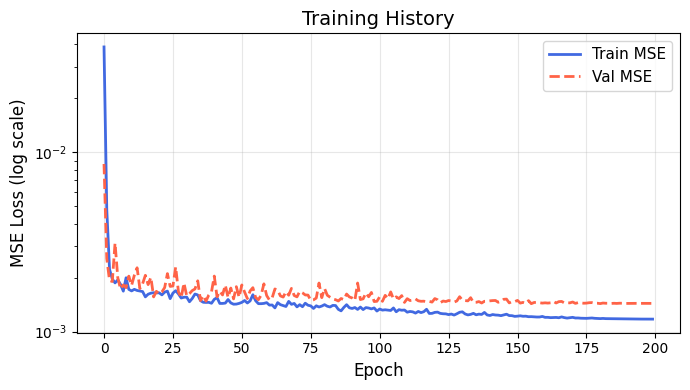

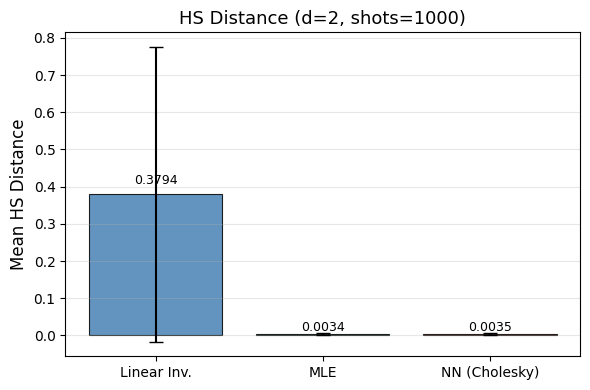


Example state (index 0):
  True ρ:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.31170475+0.j         0.0717606 +0.19681566j]
 [0.0717606 -0.19681566j 0.68829525+0.j        ]]
  Pred ρ:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.34198279+0.j         0.07501319+0.20462187j]
 [0.07501319-0.20462187j 0.65801721+0.j        ]]


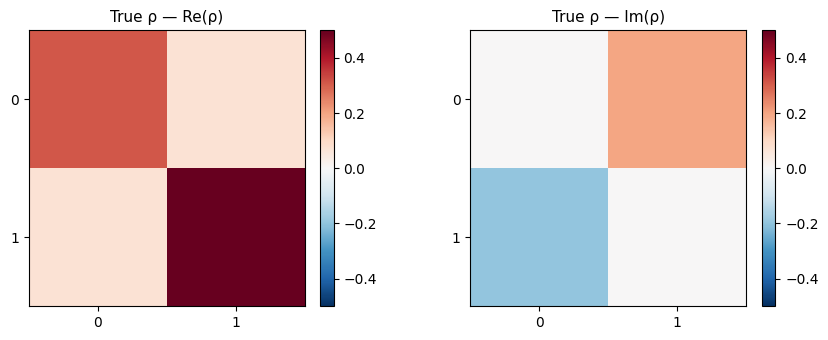

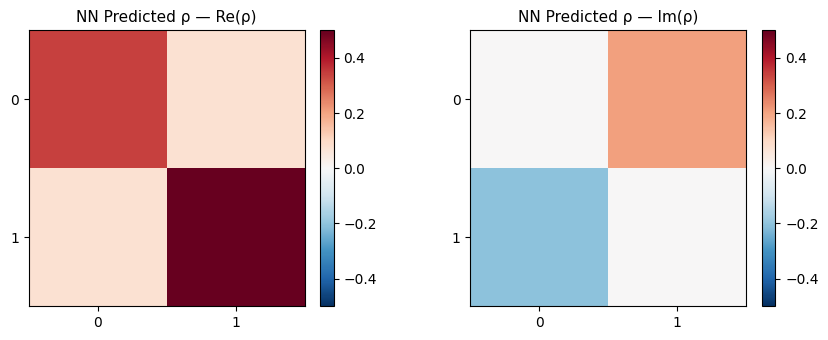


Running shot-scaling experiment...

  shots = 10

Evaluating baselines on 50 test states...
  50/50

  shots = 50

Evaluating baselines on 50 test states...
  50/50

  shots = 100

Evaluating baselines on 50 test states...
  50/50

  shots = 500

Evaluating baselines on 50 test states...
  50/50

  shots = 1000

Evaluating baselines on 50 test states...
  50/50

  shots = 5000

Evaluating baselines on 50 test states...
  50/50


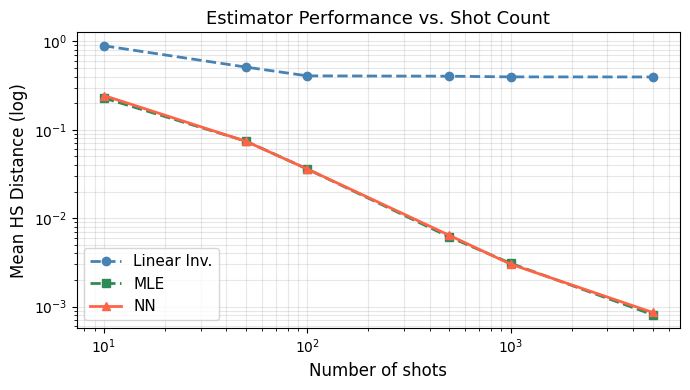


Model saved to qst_model.pt


In [17]:


# MAIN EXPERIMENT


def main():
    # ── Configuration ─────────────────────────────────────────────────────────
    D          = 2          # Hilbert space dimension (2 = qubit, 3 = qutrit …)
    N_TRAIN    = 8_000      # training samples
    N_VAL      = 1_000      # validation samples
    N_TEST     = 200        # test samples (baselines are slow so keep <500)
    N_SHOTS    = 1_000      # measurement shots per state during training
    EPOCHS     = 200
    BATCH_SIZE = 256
    LR         = 1e-3
    HIDDEN_DIM = 512
    N_HIDDEN   = 4
    DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

    print("═" * 60)
    print("  Neural-Network Quantum State Tomography")
    print("  Koutný et al. (arXiv:2206.06736) — QuTiP + PyTorch")
    print("═" * 60)
    print(f"\n  Dimension  : d = {D}")
    print(f"  Train size : {N_TRAIN}")
    print(f"  Shots      : {N_SHOTS}")
    print(f"  Device     : {DEVICE}\n")

    # ── Build POVM ────────────────────────────────────────────────────────────
    povms      = pauli_povm(D)
    input_dim  = len(povms)       # number of POVM outcomes
    output_dim = D * D            # number of Cholesky parameters

    print(f"POVM: {input_dim} elements for d={D}")

    # ── Generate datasets ─────────────────────────────────────────────────────
    print("\nGenerating datasets...")
    X_train, Y_train, _          = build_dataset(N_TRAIN, D, povms, N_SHOTS, seed=0)
    X_val,   Y_val,   _          = build_dataset(N_VAL,   D, povms, N_SHOTS, seed=1)
    X_test,  Y_test,  rhos_test  = build_dataset(N_TEST,  D, povms, N_SHOTS, seed=2)

    print(f"  Train: X{list(X_train.shape)}, Y{list(Y_train.shape)}")
    print(f"  Val  : X{list(X_val.shape)},   Y{list(Y_val.shape)}")
    print(f"  Test : X{list(X_test.shape)},  Y{list(Y_test.shape)}")

    # ── Build & train model ───────────────────────────────────────────────────
    model = QSTNet(input_dim, output_dim, hidden_dim=HIDDEN_DIM, n_hidden=N_HIDDEN)
    print(f"\nModel parameters: {model.n_params():,}")

    history = train_model(model, X_train, Y_train, X_val, Y_val,
                          epochs=EPOCHS, batch_size=BATCH_SIZE,
                          lr=LR, device=DEVICE)

    # ── Evaluate NN ───────────────────────────────────────────────────────────
    print("\nEvaluating neural network...")
    nn_results = evaluate_nn(model, X_test, rhos_test, D, device=DEVICE)
    print(f"  NN  — mean HS dist : {nn_results['hs_distances'].mean():.5f} "
          f"± {nn_results['hs_distances'].std():.5f}")
    print(f"  NN  — mean fidelity: {nn_results['fidelities'].mean():.4f}")

    # ── Evaluate baselines ────────────────────────────────────────────────────
    bl_results = evaluate_baselines(X_test.numpy(), rhos_test, povms, D)
    print(f"\n  LI  — mean HS dist : {bl_results['li']['hs_distances'].mean():.5f}")
    print(f"  MLE — mean HS dist : {bl_results['mle']['hs_distances'].mean():.5f}")

    # ── Plots ─────────────────────────────────────────────────────────────────
    print("\nGenerating plots...")
    plot_training_history(history)
    plot_hs_comparison(nn_results, bl_results, title=f'HS Distance (d={D}, shots={N_SHOTS})')
   

    # Show example: true vs predicted density matrix
    idx = 0
    print("\nExample state (index 0):")
    print(f"  True ρ:\n{rhos_test[idx]}")
    print(f"  Pred ρ:\n{nn_results['rhos_pred'][idx]}")
    plot_density_matrix(rhos_test[idx],             title='True ρ')
    plot_density_matrix(nn_results['rhos_pred'][idx], title='NN Predicted ρ')

    # Optional: shot-scaling experiment (uncomment — takes a few minutes)
    print("\nRunning shot-scaling experiment...")
    shot_results = shot_scaling_experiment(
         model, rhos_test[:50], povms, D,
         shot_counts=[10, 50, 100, 500, 1000, 5000],
         device=DEVICE
     )
    plot_shot_scaling(shot_results)

    # Save model
    torch.save(model.state_dict(), 'qst_model.pt')
    print("\nModel saved to qst_model.pt")

    return model, history, nn_results, bl_results


# ──────────────────────────────────────────────────────────────────────────────
# UTILITY: LOAD AND USE A TRAINED MODEL
# ──────────────────────────────────────────────────────────────────────────────

def load_and_predict(model_path, d, hidden_dim=512, n_hidden=4):
    """
    Load a saved model and predict density matrices from frequency vectors.

    Example usage
    -------------
    model = load_and_predict('qst_model.pt', d=2)
    f = simulate_frequencies(some_rho, povms, n_shots=1000)
    X = torch.tensor(f).unsqueeze(0)   # shape (1, m)
    params = model(X)
    rho_pred = cholesky_vec_to_rho(params[0].detach().numpy(), d=2)
    """
    povms     = pauli_povm(d)
    input_dim = len(povms)
    output_dim = d * d
    model = QSTNet(input_dim, output_dim, hidden_dim=hidden_dim, n_hidden=n_hidden)
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.eval()
    return model


# ──────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    model, history, nn_res, bl_res = main()